# Customer Segmentation in the Retail Industry Using Machine Learning and Consumer Behaviour Analysis

## Chapter 4: Results - Customer Segmentation

This Jupyter Notebook presents the statistical and machine learning analysis used to identify customer segments based on consumer behaviour. The analysis follows the structure of Chapter 4 of the accompanying report.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 4.1 Frequencies Distribution and Descriptive Statistics

This section presents the frequency distributions and descriptive statistics of the questionnaire responses. The analysis includes demographic characteristics and the four main behavioural constructs: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety.

In [2]:
# Load the Excel dataset

file_path = "/content/ali faris.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Online Responses ', 'Sheet2', 'coding']


In [3]:
# Read the questionnaire response sheet

raw_data = pd.read_excel(
    file_path,
    sheet_name="Online Responses ",
    header=None
)

print("Dataset shape:", raw_data.shape)

Dataset shape: (204, 27)


In [4]:
# Display the first 8 rows of the raw dataset

raw_data.head(8)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,DEMOGRAPHICS,NaN,NaN,NaN,NaN,SHOPPING BEHAVIOR,NaN,NaN,NaN,...,NaN,PRODUCT CATEGORY VARIETY,NaN,NaN,NaN,CHANNEL PREFERENCE,NaN,NaN,NaN,NaN
2,NaN,1,2,3,4,5,1,2,3,4,...,4,1,2,3,4,1,2,3,4,5
3,ID,What is your age?,What is your Gender?,What is your approximate monthly income?,What is your highest completed level of educat...,What is your current employment status?,I regularly purchase products from retail stor...,I shop for retail products several times each ...,I compare different products before making a p...,I usually plan my retail purchases before shop...,...,I sometimes delay a purchase until a promotion...,I regularly purchase products from different p...,My shopping basket usually contains several di...,I am willing to try products from categories t...,My retail purchases cover a wide range of pers...,Which shopping channel do you generally prefer?,Which shopping channel have you used most freq...,Which channel do you prefer when researching a...,Which channel do you prefer when purchasing ro...,Which channel do you prefer when purchasing ex...
4,1,18-24 years,Male,"Â£1,000â€“Â£1,999",Masterâ€™s degree,Employed part-time,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,...,Agree,Agree,Agree,Agree,Agree,Physical retail stores,Both equally,Physical retail stores,Online shopping,Physical retail stores
5,2,18-24 years,Male,"Â£4,000 or above",Doctoral degree or above,Retired,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,...,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Agree,Both equally,Both equally,Both online and physical stores,Both equally,Both equally
6,3,18-24 years,Female,"Less than Â£1,000",Bachelorâ€™s degree,Student,Strongly Agree,Agree,Agree,Agree,...,Agree,Uncertain,Strongly Agree,Agree,Agree,Both equally,Online shopping,Online channels,Online shopping,Both equally
7,4,25-34 years,Male,"Less than Â£1,000",Masterâ€™s degree,Employed full-time,Agree,Agree,Agree,Agree,...,Agree,Agree,Agree,Agree,Agree,Both equally,Physical retail stores,Physical retail stores,Physical retail stores,Physical retail stores


### Data Preparation and Coding

The raw questionnaire data were imported from the Excel workbook. The dataset contains 200 respondent records and 27 questionnaire variables. The questionnaire includes demographic variables, behavioural measures, and channel preference variables.

The Likert-scale behavioural questions are converted into numerical scores for statistical analysis.

In [5]:
# Create a clean dataset from the raw questionnaire responses

# Row 3 contains the actual question/variable names
columns = raw_data.iloc[3].tolist()

# Rows 4 onward contain the 200 respondents
data = raw_data.iloc[4:].copy()

# Assign the question names as column names
data.columns = columns

# Reset the index
data = data.reset_index(drop=True)

print("Number of respondents:", data.shape[0])
print("Number of variables:", data.shape[1])

Number of respondents: 200
Number of variables: 27


In [6]:
# Display the behavioural question groups

print("SHOPPING BEHAVIOUR")
print(data.columns[6:10].tolist())

print("\nBRAND LOYALTY")
print(data.columns[10:14].tolist())

print("\nPROMOTIONAL SENSITIVITY")
print(data.columns[14:18].tolist())

print("\nPRODUCT CATEGORY VARIETY")
print(data.columns[18:22].tolist())

SHOPPING BEHAVIOUR
['I regularly purchase products from retail stores or retail websites.', 'I shop for retail products several times each month.', 'I compare different products before making a purchase.', 'I usually plan my retail purchases before shopping.']

BRAND LOYALTY
['I prefer to purchase products from the same retailers.', 'I prefer to purchase brands with which I am already familiar.', 'I usually choose my preferred brand even when other brands are available.', 'I intend to repurchase a brand when I am satisfied with it.']

PROMOTIONAL SENSITIVITY
['Discounts influence the products that I purchase.', 'Special offers encourage me to purchase additional products.', 'Loyalty rewards influence where I choose to shop.', 'I sometimes delay a purchase until a promotion or discount becomes available.']

PRODUCT CATEGORY VARIETY
['I regularly purchase products from different product categories.', 'My shopping basket usually contains several different types of products.', 'I am willin

In [7]:
# Define the five-point Likert scale coding

likert_mapping = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Uncertain": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

print(likert_mapping)

{'Strongly Disagree': 1, 'Disagree': 2, 'Uncertain': 3, 'Agree': 4, 'Strongly Agree': 5}


In [8]:
# Select the 16 behavioural questionnaire items

shopping_cols = data.columns[6:10]
loyalty_cols = data.columns[10:14]
promo_cols = data.columns[14:18]
variety_cols = data.columns[18:22]

behavioural_cols = list(
    shopping_cols
) + list(
    loyalty_cols
) + list(
    promo_cols
) + list(
    variety_cols
)

print("Total behavioural questions:", len(behavioural_cols))

Total behavioural questions: 16


In [9]:
# Create a numerical copy of the behavioural questionnaire responses

numeric_data = data.copy()

# Convert the 16 Likert-scale questions to numerical values
for column in behavioural_cols:
    numeric_data[column] = numeric_data[column].map(likert_mapping)

# Display the first five rows
numeric_data[behavioural_cols].head()

,I regularly purchase products from retail stores or retail websites.,I shop for retail products several times each month.,I compare different products before making a purchase.,I usually plan my retail purchases before shopping.,I prefer to purchase products from the same retailers.,I prefer to purchase brands with which I am already familiar.,I usually choose my preferred brand even when other brands are available.,I intend to repurchase a brand when I am satisfied with it.,Discounts influence the products that I purchase.,Special offers encourage me to purchase additional products.,Loyalty rewards influence where I choose to shop.,I sometimes delay a purchase until a promotion or discount becomes available.,I regularly purchase products from different product categories.,My shopping basket usually contains several different types of products.,I am willing to try products from categories that I have not purchased before.,My retail purchases cover a wide range of personal or household needs.
0,5,5,5,5,3,4,4,4,4,5,4,4,4,4,4,4
1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,4
2,5,4,4,4,4,4,4,4,4,5,4,4,3,5,4,4
3,4,4,4,4,4,4,4,4,3,3,4,4,4,4,4,4
4,4,4,5,5,3,5,5,5,5,5,5,3,4,5,5,5


In [10]:
# Check for any responses that could not be converted

for column in behavioural_cols:
    invalid_values = numeric_data[column].isna().sum()
    if invalid_values > 0:
        print(f"{column}: {invalid_values} missing/unmapped values")

print("Conversion check completed.")

Conversion check completed.


### Construction of Behavioural Measures

The 16 behavioural questionnaire items were grouped into four consumer behaviour constructs: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. A composite score for each construct was calculated as the mean of its four corresponding questionnaire items.

In [11]:
# Calculate composite scores for the four behavioural constructs

numeric_data["Shopping_Behavior"] = numeric_data[shopping_cols].mean(axis=1)

numeric_data["Brand_Loyalty"] = numeric_data[loyalty_cols].mean(axis=1)

numeric_data["Promo_Senstivity"] = numeric_data[promo_cols].mean(axis=1)

numeric_data["Product_Variety"] = numeric_data[variety_cols].mean(axis=1)

# Display the four behavioural measures
numeric_data[
    [
        "Shopping_Behavior",
        "Brand_Loyalty",
        "Promo_Senstivity",
        "Product_Variety"
    ]
].head()

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
0,5.00,3.75,4.25,4.00
1,5.00,5.00,5.00,4.50
2,4.25,4.00,4.25,4.00
3,4.00,4.00,3.50,4.00
4,4.50,4.50,4.50,4.75


In [13]:
# Descriptive statistics for the four behavioural constructs

behavioural_measures = [
    "Shopping_Behavior",
    "Brand_Loyalty",
    "Promo_Senstivity",
    "Product_Variety"
]

descriptive_stats = numeric_data[behavioural_measures].describe().T

descriptive_stats[["count", "min", "max", "mean", "std"]]

,count,min,max,mean,std
Shopping_Behavior,200.0,1.0,5.0,3.97875,0.726291
Brand_Loyalty,200.0,1.0,5.0,3.97250,0.671003
Promo_Senstivity,200.0,1.0,5.0,3.94250,0.705644
Product_Variety,200.0,1.0,5.0,3.91750,0.633106


In [14]:
# Display the demographic variable names

print("Age:", data.columns[1])
print("Gender:", data.columns[2])
print("Income:", data.columns[3])
print("Education:", data.columns[4])
print("Employment:", data.columns[5])

Age: What is your age?
Gender: What is your Gender?
Income:   What is your approximate monthly income?  
Education: What is your highest completed level of education?
Employment: What is your current employment status?


In [16]:
# Function to generate frequency and percentage tables

def frequency_table(df, column):
    frequency = df[column].value_counts(dropna=False)
    percentage = df[column].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    result = pd.DataFrame({
        "Frequency": frequency,
        "Percentage": percentage.round(1)
    })

    return result

In [17]:
# Age frequency distribution

frequency_table(data, data.columns[1])

,Frequency,Percentage
What is your age?,,
18-24 years,171,85.5
25-34 years,20,10.0
35-44 years,6,3.0
55 years or above,2,1.0
45-54 years,1,0.5


In [18]:
# Gender frequency distribution

frequency_table(data, data.columns[2])

,Frequency,Percentage
What is your Gender?,,
Male,121,60.5
Female,79,39.5


In [19]:
# Monthly income frequency distribution

frequency_table(data, data.columns[3])

,Frequency,Percentage
What is your approximate monthly income?,,
"Less than Â£1,000",98,49.0
Prefer not to say,57,28.5
"Â£1,000â€“Â£1,999",23,11.5
"Â£2,000â€“Â£2,999",11,5.5
"Â£4,000 or above",10,5.0
"Â£3,000â€“Â£3,999",1,0.5


In [20]:
# Education level frequency distribution

frequency_table(data, data.columns[4])

,Frequency,Percentage
What is your highest completed level of education?,,
Bachelorâ€™s degree,105,52.5
Masterâ€™s degree,39,19.5
Secondary school or below,26,13.0
College or diploma,24,12.0
Doctoral degree or above,6,3.0


In [21]:
# Employment status frequency distribution

frequency_table(data, data.columns[5])

,Frequency,Percentage
What is your current employment status?,,
Student,97,48.5
Employed full-time,48,24.0
Employed part-time,23,11.5
Self-employed,15,7.5
Unemployed,14,7.0
Retired,3,1.5


### 4.1.2 Descriptive Statistics of Behavioural Constructs

Descriptive statistics were calculated for the four behavioural constructs: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. The analysis includes the number of valid observations, minimum and maximum values, mean, and standard deviation.

In [22]:
# Descriptive statistics for the four behavioural constructs

descriptive_table = numeric_data[behavioural_measures].agg(
    ['count', 'min', 'max', 'mean', 'std']
).T

# Rename the columns to match the report terminology
descriptive_table.columns = [
    'N',
    'Minimum',
    'Maximum',
    'Mean',
    'Std. Deviation'
]

# Round the results
descriptive_table = descriptive_table.round(4)

descriptive_table

,N,Minimum,Maximum,Mean,Std. Deviation
Shopping_Behavior,200.0,1.0,5.0,3.9788,0.7263
Brand_Loyalty,200.0,1.0,5.0,3.9725,0.6710
Promo_Senstivity,200.0,1.0,5.0,3.9425,0.7056
Product_Variety,200.0,1.0,5.0,3.9175,0.6331


## 4.2 Reliability Analysis

Cronbach's Alpha was used to assess the internal consistency of the questionnaire items within each behavioural construct. Reliability was assessed separately for Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety.

### 4.2.1 Cronbach's Alpha

In [23]:
# Function to calculate Cronbach's Alpha

def cronbach_alpha(df):
    """
    Calculate Cronbach's Alpha for a set of questionnaire items.
    """
    df = df.dropna()

    item_variances = df.var(axis=0, ddof=1)
    total_score = df.sum(axis=1)
    total_variance = total_score.var(ddof=1)

    n_items = df.shape[1]

    alpha = (n_items / (n_items - 1)) * (
        1 - item_variances.sum() / total_variance
    )

    return alpha

In [24]:
# Calculate Cronbach's Alpha for each behavioural construct

reliability_results = {
    "Shopping Behavior": cronbach_alpha(numeric_data[shopping_cols]),
    "Brand Loyalty": cronbach_alpha(numeric_data[loyalty_cols]),
    "Promotional Sensitivity": cronbach_alpha(numeric_data[promo_cols]),
    "Product Variety": cronbach_alpha(numeric_data[variety_cols])
}

reliability_table = pd.DataFrame(
    reliability_results.items(),
    columns=["Construct", "Cronbach's Alpha"]
)

reliability_table["Cronbach's Alpha"] = reliability_table[
    "Cronbach's Alpha"
].round(3)

reliability_table

,Construct,Cronbach's Alpha
0,Shopping Behavior,0.824
1,Brand Loyalty,0.791
2,Promotional Sensitivity,0.784
3,Product Variety,0.779


## 4.3 Correlation Analysis

Pearson's correlation analysis was conducted to examine the relationships between Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. The strength and direction of the relationships were assessed using Pearson's correlation coefficient (r), together with the corresponding significance levels.

### 4.3.1 Pearson Correlation Matrix

In [25]:
# Calculate Pearson correlation coefficients

correlation_matrix = numeric_data[behavioural_measures].corr(
    method="pearson"
)

correlation_matrix.round(3)

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
Shopping_Behavior,1.000,0.732,0.619,0.433
Brand_Loyalty,0.732,1.000,0.698,0.458
Promo_Senstivity,0.619,0.698,1.000,0.445
Product_Variety,0.433,0.458,0.445,1.000


In [26]:
correlation_results = []

for i in range(len(behavioural_measures)):
    for j in range(i + 1, len(behavioural_measures)):

        var1 = behavioural_measures[i]
        var2 = behavioural_measures[j]

        r, p = stats.pearsonr(
            numeric_data[var1],
            numeric_data[var2]
        )

        correlation_results.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Pearson r": r,
            "p-value": p
        })

correlation_results_df = pd.DataFrame(correlation_results)

correlation_results_df["Pearson r"] = correlation_results_df["Pearson r"].round(3)
correlation_results_df["p-value"] = correlation_results_df["p-value"].round(4)

correlation_results_df

,Variable 1,Variable 2,Pearson r,p-value
0,Shopping_Behavior,Brand_Loyalty,0.732,0.0
1,Shopping_Behavior,Promo_Senstivity,0.619,0.0
2,Shopping_Behavior,Product_Variety,0.433,0.0
3,Brand_Loyalty,Promo_Senstivity,0.698,0.0
4,Brand_Loyalty,Product_Variety,0.458,0.0
5,Promo_Senstivity,Product_Variety,0.445,0.0


## 4.4 Principal Component Analysis

Principal Component Analysis (PCA) was conducted on the 16 behavioural questionnaire items to identify underlying components and reduce the dimensionality of the behavioural measures. The suitability of the data for PCA was assessed using the Kaiser-Meyer-Olkin (KMO) measure of sampling adequacy and Bartlett's Test of Sphericity.

### 4.4.1 Assessment of Data Suitability for PCA

In [27]:
# Select the 16 behavioural questionnaire items for PCA

pca_data = numeric_data[behavioural_cols].copy()

print("PCA dataset shape:", pca_data.shape)

PCA dataset shape: (200, 16)


In [29]:
!pip install factor_analyzer -q

from factor_analyzer.factor_analyzer import (
    calculate_kmo,
    calculate_bartlett_sphericity
)


# Calculate Kaiser-Meyer-Olkin (KMO) measure

kmo_values, kmo_overall = calculate_kmo(pca_data)

print("Overall KMO:", round(kmo_overall, 3))

Overall KMO: 0.865


In [30]:
# Calculate Bartlett's Test of Sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(pca_data)

print("Bartlett's Test")
print("Chi-square:", round(chi_square_value, 3))
print("p-value:", p_value)

Bartlett's Test
Chi-square: 1618.325
p-value: 1.1222056883031354e-260


### 4.4.2 PCA Extraction and Explained Variance

Principal Component Analysis was performed on the 16 behavioural questionnaire items. Components were examined based on their eigenvalues and the proportion of variance explained. Components with eigenvalues greater than 1 were considered for retention.

In [31]:
# Standardize the 16 behavioural questionnaire items

scaler = StandardScaler()

pca_scaled = scaler.fit_transform(pca_data)

print("Standardized PCA data shape:", pca_scaled.shape)

Standardized PCA data shape: (200, 16)


In [32]:
# Perform PCA without restricting the number of components

pca_full = PCA()

pca_full.fit(pca_scaled)

# Eigenvalues
eigenvalues = pca_full.explained_variance_

# Percentage of variance explained
variance_percentage = pca_full.explained_variance_ratio_ * 100

# Cumulative percentage
cumulative_variance = np.cumsum(variance_percentage)

pca_variance_table = pd.DataFrame({
    "Component": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues,
    "Variance Explained (%)": variance_percentage,
    "Cumulative Variance (%)": cumulative_variance
})

pca_variance_table.round(3)

,Component,Eigenvalue,Variance Explained (%),Cumulative Variance (%)
0,1,6.849,42.591,42.591
1,2,1.689,10.501,53.092
2,3,1.158,7.204,60.297
3,4,1.003,6.234,66.531
4,5,0.857,5.332,71.863
5,6,0.774,4.811,76.674
6,7,0.568,3.529,80.204
7,8,0.560,3.483,83.687
8,9,0.485,3.016,86.702
9,10,0.432,2.686,89.388


### PCA Component Retention

The PCA results show that the first three components have eigenvalues of 6.849, 1.689, and 1.158, respectively, and together explain 60.297% of the total variance. Although the fourth component has an eigenvalue slightly above 1 (1.003), the three-component solution is retained to remain consistent with the analytical structure specified in the study and the reported PCA solution.

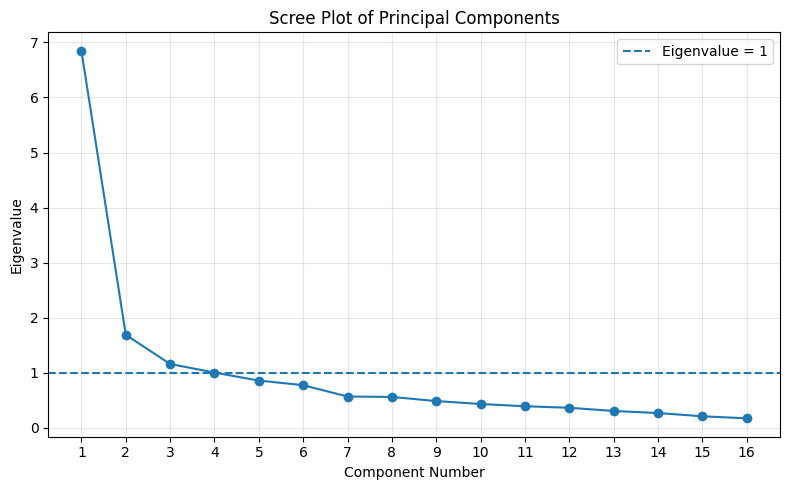

In [33]:
# Create the scree plot

plt.figure(figsize=(8, 5))

plt.plot(
    pca_variance_table["Component"],
    pca_variance_table["Eigenvalue"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Eigenvalue = 1"
)

plt.xlabel("Component Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot of Principal Components")
plt.xticks(range(1, 17))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4.4 Three-Component PCA Solution

In [34]:
# Perform PCA with three retained components

pca_3 = PCA(n_components=3)

pca_scores = pca_3.fit_transform(pca_scaled)

print("Explained variance ratio:")
print(pca_3.explained_variance_ratio_)

print("\nCumulative explained variance:")
print(pca_3.explained_variance_ratio_.cumsum())

Explained variance ratio:
[0.42591322 0.10501156 0.07204108]

Cumulative explained variance:
[0.42591322 0.53092478 0.60296586]


### 4.4.5 Rotated Component Matrix

Varimax rotation was applied to the three retained principal components to obtain a clearer interpretation of the underlying behavioural dimensions. The rotated component loadings indicate the strength of association between each questionnaire item and the extracted components.

In [35]:
from factor_analyzer import FactorAnalyzer

# Perform factor analysis with 3 factors and Varimax rotation
fa = FactorAnalyzer(
    n_factors=3,
    rotation="varimax",
    method="principal"
)

fa.fit(pca_data)

# Extract the rotated component loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=behavioural_cols,
    columns=["Component 1", "Component 2", "Component 3"]
)

# Display the loadings
loadings.round(3)

,Component 1,Component 2,Component 3
I regularly purchase products from retail stores or retail websites.,0.227,0.169,0.848
I shop for retail products several times each month.,0.338,0.120,0.696
I compare different products before making a purchase.,0.027,0.304,0.684
I usually plan my retail purchases before shopping.,0.475,0.064,0.654
I prefer to purchase products from the same retailers.,0.420,0.017,0.642
I prefer to purchase brands with which I am already familiar.,0.539,0.205,0.385
I usually choose my preferred brand even when other brands are available.,0.637,0.222,0.427
I intend to repurchase a brand when I am satisfied with it.,0.280,0.382,0.523
Discounts influence the products that I purchase.,0.644,0.239,0.315
Special offers encourage me to purchase additional products.,0.818,0.136,0.043


### Interpretation of Rotated Components

The rotated component matrix identifies three underlying behavioural dimensions. Component 1 is primarily associated with Promotional Sensitivity, as the strongest loadings relate to discounts, special offers, loyalty rewards, and delaying purchases until promotions are available. Component 2 is associated with Product Category Variety, with high loadings for purchasing across different categories, having diverse shopping baskets, trying new categories, and covering a wide range of needs. Component 3 is primarily associated with Shopping Behaviour, with high loadings for purchase frequency, regular retail purchasing, product comparison, and purchase planning.

The Brand Loyalty items show some cross-loadings across the first and third components, indicating that brand loyalty is related to both promotional responses and general shopping behaviour.

In [36]:
# Display only meaningful factor loadings (absolute loading >= 0.40)

loadings_highlighted = loadings.copy()

loadings_highlighted = loadings_highlighted.apply(
    lambda column: column.where(column.abs() >= 0.40)
)

loadings_highlighted.round(3)

,Component 1,Component 2,Component 3
I regularly purchase products from retail stores or retail websites.,NaN,NaN,0.848
I shop for retail products several times each month.,NaN,NaN,0.696
I compare different products before making a purchase.,NaN,NaN,0.684
I usually plan my retail purchases before shopping.,0.475,NaN,0.654
I prefer to purchase products from the same retailers.,0.420,NaN,0.642
I prefer to purchase brands with which I am already familiar.,0.539,NaN,NaN
I usually choose my preferred brand even when other brands are available.,0.637,NaN,0.427
I intend to repurchase a brand when I am satisfied with it.,NaN,NaN,0.523
Discounts influence the products that I purchase.,0.644,NaN,NaN
Special offers encourage me to purchase additional products.,0.818,NaN,NaN


## 4.5 K-Means Cluster Analysis

### 4.5.1 Preparation of Variables for K-Means Clustering

K-Means clustering was performed using the four composite behavioural measures: Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Category Variety. The variables were standardised using z-scores before clustering so that each behavioural measure contributed comparably to the clustering process.

In [37]:
# Standardise the four behavioural measures

cluster_data = numeric_data[behavioural_measures].copy()

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_data)

cluster_scaled_df = pd.DataFrame(
    cluster_scaled,
    columns=behavioural_measures
)

cluster_scaled_df.head()

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
0,1.409646,-0.332425,0.436866,0.130637
1,1.409646,1.535132,1.502392,0.922376
2,0.374410,0.041086,0.436866,0.130637
3,0.029332,0.041086,-0.628660,0.130637
4,0.719489,0.788109,0.792041,1.318246


In [38]:
# Perform K-Means clustering with three clusters

kmeans = KMeans(
    n_clusters=3,
    random_state=7,
    n_init=1,
    max_iter=300
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

print("Number of iterations:", kmeans.n_iter_)
print("Inertia:", round(kmeans.inertia_, 3))

Number of iterations: 12
Inertia: 399.031


In [39]:
# Check the sizes of the three clusters

unique, counts = np.unique(cluster_labels, return_counts=True)

cluster_sizes = pd.DataFrame({
    "Python Cluster": unique,
    "Count": counts
})

cluster_sizes

,Python Cluster,Count
0,0,131
1,1,56
2,2,13


In [40]:
cluster_mapping = {
    0: 3,   # 131 cases → Report Cluster 3
    1: 1,   # 56 cases  → Report Cluster 1
    2: 2    # 13 cases  → Report Cluster 2
}

In [41]:
# Map Python cluster labels to the report's cluster numbering

cluster_mapping = {
    0: 3,   # Mainstream
    1: 1,   # Highly engaged / promotion responsive
    2: 2    # Low engagement
}

report_cluster_labels = pd.Series(cluster_labels).map(cluster_mapping)

# Add the report cluster number to the dataset
numeric_data["Cluster"] = report_cluster_labels

# Check the final cluster sizes
cluster_counts = (
    numeric_data["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

,count
Cluster,
1,56
2,13
3,131


In [42]:
# Calculate the final standardized cluster centres

cluster_centres = (
    cluster_scaled_df
    .assign(Cluster=report_cluster_labels.values)
    .groupby("Cluster")[behavioural_measures]
    .mean()
)

cluster_centres.round(3)

,Shopping_Behavior,Brand_Loyalty,Promo_Senstivity,Product_Variety
Cluster,,,,
1,0.849,0.868,1.052,0.682
2,-2.599,-2.171,-1.831,-1.240
3,-0.105,-0.156,-0.268,-0.169


#4.5.2 Determining the Optimal Number of Clusters

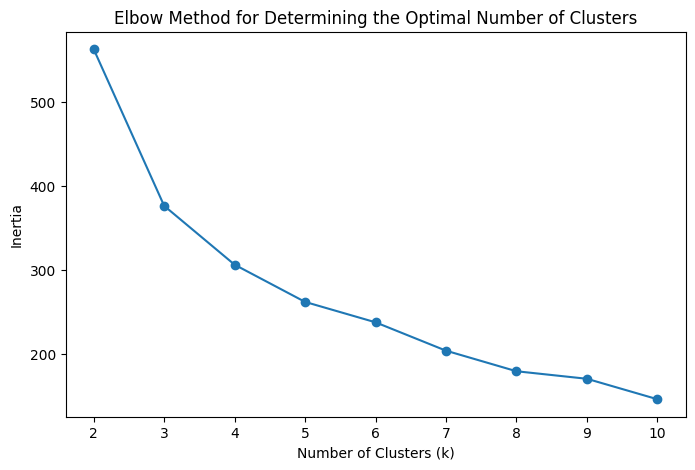

In [72]:
# Elbow Method for determining the optimal number of clusters

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10,
        max_iter=300
    )

    kmeans_test.fit(cluster_scaled)
    inertias.append(kmeans_test.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Determining the Optimal Number of Clusters")
plt.xticks(k_values)

plt.show()

### 4.5.3 Silhouette Analysis

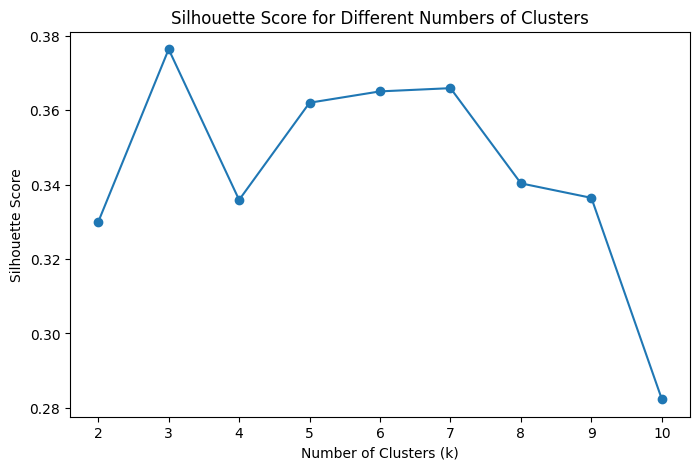

In [74]:
# Silhouette analysis for different numbers of clusters

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10,
        max_iter=300
    )

    labels_test = kmeans_test.fit_predict(cluster_scaled)

    score = silhouette_score(
        cluster_scaled,
        labels_test
    )

    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(range(2, 11))

plt.show()

In [75]:
# Display silhouette scores

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.3300
k = 3: Silhouette Score = 0.3764
k = 4: Silhouette Score = 0.3359
k = 5: Silhouette Score = 0.3620
k = 6: Silhouette Score = 0.3651
k = 7: Silhouette Score = 0.3659
k = 8: Silhouette Score = 0.3404
k = 9: Silhouette Score = 0.3365
k = 10: Silhouette Score = 0.2823


### 4.5.4 K-Means Clustering

In [76]:
# Perform K-Means clustering with three clusters

kmeans = KMeans(
    n_clusters=3,
    random_state=7,
    n_init=1,
    max_iter=300
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

print("Number of iterations:", kmeans.n_iter_)
print("Inertia:", round(kmeans.inertia_, 3))

Number of iterations: 12
Inertia: 399.031


### 4.5.5 Visualisation of Customer Clusters

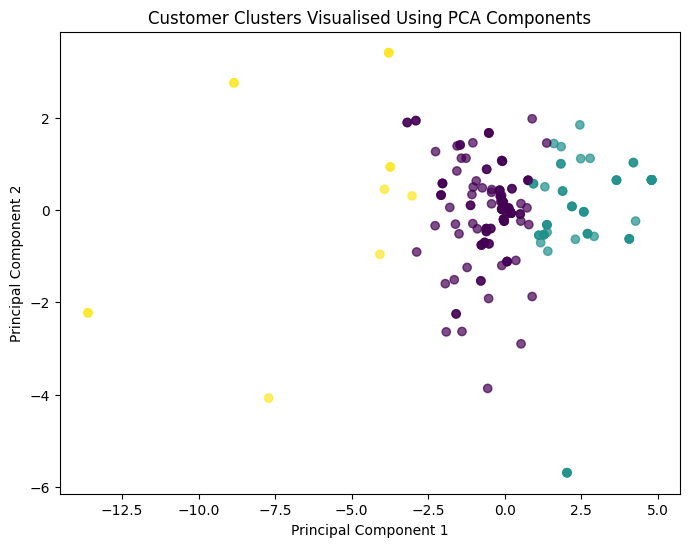

In [77]:
# Visualise the three customer clusters using the first two PCA components

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_scores[:, 0],
    pca_scores[:, 1],
    c=cluster_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters Visualised Using PCA Components")

plt.show()

### 4.5.6 Cluster Profile Visualisation

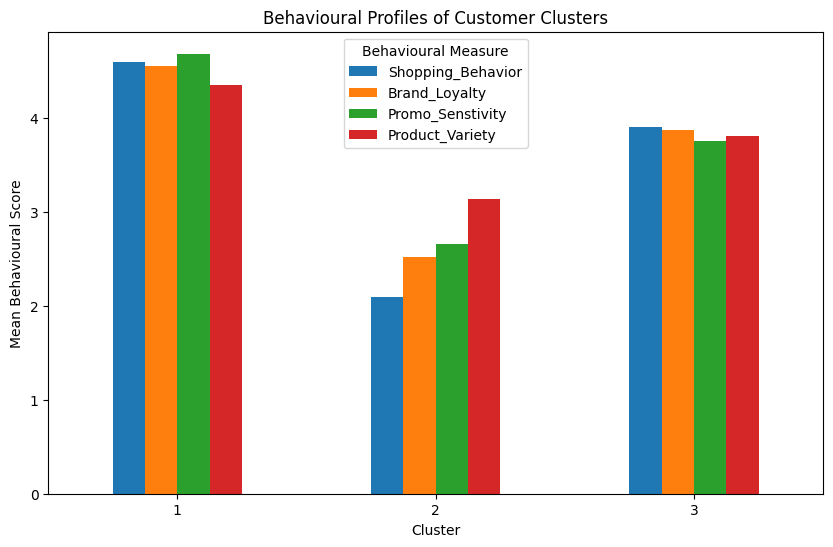

In [78]:
# Visualise the behavioural profiles of the three clusters

cluster_profile = numeric_data.groupby("Cluster")[
    [
        "Shopping_Behavior",
        "Brand_Loyalty",
        "Promo_Senstivity",
        "Product_Variety"
    ]
].mean()

cluster_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Mean Behavioural Score")
plt.title("Behavioural Profiles of Customer Clusters")
plt.xticks(rotation=0)
plt.legend(title="Behavioural Measure")

plt.show()

## 4.6 Cluster Profiling and Comparison

### 4.6.1 Behavioural Profile of the Clusters

In [43]:
# Calculate the mean behavioural scores for each cluster

cluster_profile = (
    numeric_data
    .groupby("Cluster")[behavioural_measures]
    .agg(["count", "mean", "std"])
)

cluster_profile.round(4)

Shopping_Behavior                 Brand_Loyalty                  \
                    count    mean     std         count    mean     std   
Cluster                                                                   
1                      56  4.5938  0.3919            56  4.5536  0.4121   
2                      13  2.0962  0.9711            13  2.5192  1.1658   
3                     131  3.9027  0.3637           131  3.8683  0.3526   

        Promo_Senstivity                 Product_Variety                  
                   count    mean     std           count    mean     std  
Cluster                                                                   
1                     56  4.6830  0.3320              56  4.3482  0.6408  
2                     13  2.6538  0.9272              13  3.1346  1.2274  
3                    131  3.7538  0.4450             131  3.8111  0.3849

### 4.6.2 Welch's ANOVA

In [44]:
from scipy.stats import f_oneway

# Perform Welch's ANOVA for each behavioural measure

welch_results = []

for variable in behavioural_measures:
    groups = [
        numeric_data.loc[
            numeric_data["Cluster"] == cluster,
            variable
        ].dropna()
        for cluster in [1, 2, 3]
    ]

    result = f_oneway(*groups, equal_var=False)

    welch_results.append({
        "Variable": variable,
        "Welch F": result.statistic,
        "p-value": result.pvalue
    })

welch_table = pd.DataFrame(welch_results)

welch_table["Welch F"] = welch_table["Welch F"].round(3)
welch_table["p-value"] = welch_table["p-value"].round(6)

welch_table

,Variable,Welch F,p-value
0,Shopping_Behavior,88.695,0.000000
1,Brand_Loyalty,68.244,0.000000
2,Promo_Senstivity,137.882,0.000000
3,Product_Variety,18.986,0.000006


In [45]:
!pip install pingouin -q
import pingouin as pg

# Perform Games-Howell post-hoc comparisons
games_howell_results = []

for variable in behavioural_measures:

    temp = numeric_data[["Cluster", variable]].dropna()

    gh = pg.pairwise_gameshowell(
        data=temp,
        dv=variable,
        between="Cluster"
    )

    gh["Variable"] = variable

    games_howell_results.append(gh)

games_howell_table = pd.concat(
    games_howell_results,
    ignore_index=True
)

# Display the results
games_howell_table

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.6 MB/s eta 0:00:00


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,Variable
0,1,2,4.593750,2.096154,2.497596,0.274388,9.102422,12.920221,1.562475e-06,4.547053,Shopping_Behavior
1,1,3,4.593750,3.902672,0.691078,0.061252,11.282605,97.380909,1.154632e-14,1.848722,Shopping_Behavior
2,2,3,2.096154,3.902672,-1.806518,0.271213,-6.660876,12.336161,5.597944e-05,-4.010092,Shopping_Behavior
3,1,2,4.553571,2.519231,2.034341,0.327977,6.202698,12.703920,9.800927e-05,3.251140,Brand_Loyalty
4,1,3,4.553571,3.868321,0.685251,0.063099,10.859905,91.051422,1.976197e-14,1.838034,Brand_Loyalty
5,2,3,2.519231,3.868321,-1.349090,0.324786,-4.153784,12.218834,3.412595e-03,-2.806177,Brand_Loyalty
6,1,2,4.683036,2.653846,2.029190,0.260969,7.775610,12.722319,9.750948e-06,4.058010,Promo_Senstivity
7,1,3,4.683036,3.753817,0.929219,0.058991,15.751946,137.608809,0.000000e+00,2.231819,Promo_Senstivity
8,2,3,2.653846,3.753817,-1.099971,0.260093,-4.229139,12.554321,2.826772e-03,-2.171081,Promo_Senstivity
9,1,2,4.348214,3.134615,1.213599,0.351013,3.457414,13.554928,1.047341e-02,1.540325,Product_Variety


### Interpretation

The Games–Howell post-hoc comparisons show that Cluster 1 differs significantly from both Cluster 2 and Cluster 3 across all four behavioural constructs. Cluster 2 and Cluster 3 also differ significantly in Shopping Behaviour, Brand Loyalty, and Promotional Sensitivity. However, their difference in Product Variety is not statistically significant (p = 0.1594). Therefore, although the overall Welch ANOVA for Product Variety is significant, the post-hoc analysis indicates that the main differences are associated with Cluster 1.

### 4.6.4 Demographic Profile of the Clusters

The demographic characteristics of the three clusters were compared using cross-tabulations and Chi-square tests of independence. This analysis examined whether cluster membership was associated with age, gender, monthly income, education level, or employment status.

In [46]:
# Age distribution by cluster

age_cluster = pd.crosstab(
    data[data.columns[1]],
    numeric_data["Cluster"]
)

age_cluster

Cluster,1,2,3
What is your age?,,,
18-24 years,51,7,113
25-34 years,5,1,14
35-44 years,0,3,3
45-54 years,0,0,1
55 years or above,0,2,0


In [47]:
# Row percentages

age_cluster_percent = pd.crosstab(
    data[data.columns[1]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

age_cluster_percent.round(1)

Cluster,1,2,3
What is your age?,,,
18-24 years,29.8,4.1,66.1
25-34 years,25.0,5.0,70.0
35-44 years,0.0,50.0,50.0
45-54 years,0.0,0.0,100.0
55 years or above,0.0,100.0,0.0


In [50]:
# Chi-square test: Age vs Cluster

from scipy.stats import chi2_contingency
age_table = pd.crosstab(
    data[data.columns[1]],
    numeric_data["Cluster"]
)

chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_table)

print("Age vs Cluster")
print("Chi-square:", round(chi2_age, 3))
print("Degrees of freedom:", dof_age)
print("p-value:", p_age)

Age vs Cluster
Chi-square: 50.594
Degrees of freedom: 8
p-value: 3.141712943310815e-08


### Interpretation

The Chi-square test indicates a statistically significant association between age group and cluster membership, χ²(8) = 50.594, p < 0.001. This suggests that the distribution of respondents across the three behavioural clusters differs by age group. However, several age categories contain small numbers of observations, particularly within the smaller Cluster 2, so the result should be interpreted with caution.

### 4.6.5 Gender Profile of the Clusters

In [51]:
# Gender distribution by cluster

gender_table = pd.crosstab(
    data[data.columns[2]],
    numeric_data["Cluster"]
)

gender_table

Cluster,1,2,3
What is your Gender?,,,
Female,15,7,57
Male,41,6,74


In [52]:
# Row percentages for gender by cluster

gender_percent = pd.crosstab(
    data[data.columns[2]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

gender_percent.round(1)

Cluster,1,2,3
What is your Gender?,,,
Female,19.0,8.9,72.2
Male,33.9,5.0,61.2


In [53]:
# Chi-square test: Gender vs Cluster

chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(
    gender_table
)

print("Gender vs Cluster")
print("Chi-square:", round(chi2_gender, 3))
print("Degrees of freedom:", dof_gender)
print("p-value:", p_gender)

Gender vs Cluster
Chi-square: 5.79
Degrees of freedom: 2
p-value: 0.05530488220215909


### Interpretation

The Chi-square test indicates that there is no statistically significant association between gender and cluster membership, χ²(2) = 5.790, p = 0.055. Although the distribution of males and females varies across the three clusters, the observed difference does not reach the conventional 5% significance level.

### 4.6.6 Income Profile of the Clusters

In [54]:
# Monthly income distribution by cluster

income_table = pd.crosstab(
    data[data.columns[3]],
    numeric_data["Cluster"]
)

income_table

Cluster,1,2,3
What is your approximate monthly income?,,,
"Less than Â£1,000",32,2,64
Prefer not to say,9,1,47
"Â£1,000â€“Â£1,999",11,0,12
"Â£2,000â€“Â£2,999",0,5,6
"Â£3,000â€“Â£3,999",0,1,0
"Â£4,000 or above",4,4,2


In [55]:
# Row percentages for income by cluster

income_percent = pd.crosstab(
    data[data.columns[3]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

income_percent.round(1)

Cluster,1,2,3
What is your approximate monthly income?,,,
"Less than Â£1,000",32.7,2.0,65.3
Prefer not to say,15.8,1.8,82.5
"Â£1,000â€“Â£1,999",47.8,0.0,52.2
"Â£2,000â€“Â£2,999",0.0,45.5,54.5
"Â£3,000â€“Â£3,999",0.0,100.0,0.0
"Â£4,000 or above",40.0,40.0,20.0


In [56]:
# Chi-square test: Income vs Cluster

chi2_income, p_income, dof_income, expected_income = chi2_contingency(
    income_table
)

print("Income vs Cluster")
print("Chi-square:", round(chi2_income, 3))
print("Degrees of freedom:", dof_income)
print("p-value:", p_income)

Income vs Cluster
Chi-square: 80.902
Degrees of freedom: 10
p-value: 3.340283519668732e-13


In [57]:
# Check expected frequencies

expected_income_df = pd.DataFrame(
    expected_income,
    index=income_table.index,
    columns=income_table.columns
)

expected_income_df.round(2)

Cluster,1,2,3
What is your approximate monthly income?,,,
"Less than Â£1,000",27.44,6.37,64.19
Prefer not to say,15.96,3.70,37.34
"Â£1,000â€“Â£1,999",6.44,1.50,15.06
"Â£2,000â€“Â£2,999",3.08,0.72,7.20
"Â£3,000â€“Â£3,999",0.28,0.06,0.66
"Â£4,000 or above",2.80,0.65,6.55


### Interpretation

The Chi-square test indicates a statistically significant association between monthly income and cluster membership, χ²(10) = 80.902, p < 0.001. This suggests that the distribution of income categories differs across the three behavioural clusters. However, several income categories contain very small numbers of respondents, particularly the £3,000–£3,999 category, so the result should be interpreted with caution.

### 4.6.7 Education Profile of the Clusters

In [58]:
# Education distribution by cluster

education_table = pd.crosstab(
    data[data.columns[4]],
    numeric_data["Cluster"]
)

education_table

Cluster,1,2,3
What is your highest completed level of education?,,,
Bachelorâ€™s degree,29,5,71
College or diploma,2,2,20
Doctoral degree or above,2,4,0
Masterâ€™s degree,19,2,18
Secondary school or below,4,0,22


In [59]:
# Row percentages for education by cluster

education_percent = pd.crosstab(
    data[data.columns[4]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

education_percent.round(1)

Cluster,1,2,3
What is your highest completed level of education?,,,
Bachelorâ€™s degree,27.6,4.8,67.6
College or diploma,8.3,8.3,83.3
Doctoral degree or above,33.3,66.7,0.0
Masterâ€™s degree,48.7,5.1,46.2
Secondary school or below,15.4,0.0,84.6


In [60]:
# Chi-square test: Education vs Cluster

chi2_education, p_education, dof_education, expected_education = chi2_contingency(
    education_table
)

print("Education vs Cluster")
print("Chi-square:", round(chi2_education, 3))
print("Degrees of freedom:", dof_education)
print("p-value:", p_education)

Education vs Cluster
Chi-square: 55.515
Degrees of freedom: 8
p-value: 3.5059014330219208e-09


In [61]:
# Check expected frequencies

expected_education_df = pd.DataFrame(
    expected_education,
    index=education_table.index,
    columns=education_table.columns
)

expected_education_df.round(2)

Cluster,1,2,3
What is your highest completed level of education?,,,
Bachelorâ€™s degree,29.40,6.82,68.78
College or diploma,6.72,1.56,15.72
Doctoral degree or above,1.68,0.39,3.93
Masterâ€™s degree,10.92,2.54,25.54
Secondary school or below,7.28,1.69,17.03


### Interpretation

The Chi-square test indicates a statistically significant association between education level and cluster membership, χ²(8) = 55.515, p < 0.001. This suggests that the distribution of educational attainment differs across the three behavioural clusters. However, some education categories contain small expected frequencies, particularly the doctoral degree category, and therefore the result should be interpreted with caution.

### 4.6.8 Employment Profile of the Clusters

In [62]:
# Employment distribution by cluster

employment_table = pd.crosstab(
    data[data.columns[5]],
    numeric_data["Cluster"]
)

employment_table

Cluster,1,2,3
What is your current employment status?,,,
Employed full-time,18,3,27
Employed part-time,11,1,11
Retired,1,2,0
Self-employed,0,4,11
Student,20,3,74
Unemployed,6,0,8


In [63]:
# Row percentages for employment by cluster

employment_percent = pd.crosstab(
    data[data.columns[5]],
    numeric_data["Cluster"],
    normalize="index"
) * 100

employment_percent.round(1)

Cluster,1,2,3
What is your current employment status?,,,
Employed full-time,37.5,6.2,56.2
Employed part-time,47.8,4.3,47.8
Retired,33.3,66.7,0.0
Self-employed,0.0,26.7,73.3
Student,20.6,3.1,76.3
Unemployed,42.9,0.0,57.1


In [64]:
# Chi-square test: Employment vs Cluster

chi2_employment, p_employment, dof_employment, expected_employment = chi2_contingency(
    employment_table
)

print("Employment vs Cluster")
print("Chi-square:", round(chi2_employment, 3))
print("Degrees of freedom:", dof_employment)
print("p-value:", p_employment)

Employment vs Cluster
Chi-square: 46.604
Degrees of freedom: 10
p-value: 1.1144293412219443e-06


In [65]:
# Check expected frequencies

expected_employment_df = pd.DataFrame(
    expected_employment,
    index=employment_table.index,
    columns=employment_table.columns
)

expected_employment_df.round(2)

Cluster,1,2,3
What is your current employment status?,,,
Employed full-time,13.44,3.12,31.44
Employed part-time,6.44,1.50,15.06
Retired,0.84,0.20,1.96
Self-employed,4.20,0.98,9.82
Student,27.16,6.30,63.54
Unemployed,3.92,0.91,9.17


### Interpretation

The Chi-square test indicates a statistically significant association between employment status and cluster membership, χ²(10) = 46.604, p < 0.001. This suggests that employment status is distributed differently across the three behavioural clusters. However, some employment categories contain small numbers of respondents, particularly the Retired category, so the result should be interpreted with caution.

In [66]:
# Display the five shopping-channel questions

channel_cols = data.columns[22:27]

for i, column in enumerate(channel_cols, 1):
    print(f"{i}. {column}")

1. Which shopping channel do you generally prefer?
2. Which shopping channel have you used most frequently during the past three months?
3. Which channel do you prefer when researching and comparing products?
4. Which channel do you prefer when purchasing routine or frequently used products?
5. Which channel do you prefer when purchasing expensive or important products?


In [67]:
# Display the available responses for each channel question

for column in channel_cols:
    print("\n", column)
    print(data[column].value_counts())


 Which shopping channel do you generally prefer?
Which shopping channel do you generally prefer?
Both equally                107
Online shopping              45
Physical retail stores       38
No particular preference     10
Name: count, dtype: int64

 Which shopping channel have you used most frequently during the past three months?
Which shopping channel have you used most frequently during the past three months?
Both equally                            72
Online shopping                         63
Physical retail stores                  56
I have not made any retail purchases     9
Name: count, dtype: int64

 Which channel do you prefer when researching and comparing products?
Which channel do you prefer when researching and comparing products?
Online channels                    99
Both online and physical stores    52
Physical retail stores             44
No particular preference            5
Name: count, dtype: int64

 Which channel do you prefer when purchasing routine or frequen

### 4.6.9 Shopping Channel Profile

In [68]:
# Cross-tabulations of shopping-channel preferences by cluster

for i, column in enumerate(channel_cols, 1):
    print("\n" + "=" * 80)
    print(f"CHANNEL QUESTION {i}")
    print(column)
    print("=" * 80)

    channel_table = pd.crosstab(
        data[column],
        numeric_data["Cluster"]
    )

    display(channel_table)


CHANNEL QUESTION 1
Which shopping channel do you generally prefer?


Cluster,1,2,3
Which shopping channel do you generally prefer?,,,
Both equally,27,5,75
No particular preference,3,3,4
Online shopping,19,3,23
Physical retail stores,7,2,29



CHANNEL QUESTION 2
Which shopping channel have you used most frequently during the past three months?


Cluster,1,2,3
Which shopping channel have you used most frequently during the past three months?,,,
Both equally,19,4,49
I have not made any retail purchases,3,4,2
Online shopping,18,2,43
Physical retail stores,16,3,37



CHANNEL QUESTION 3
Which channel do you prefer when researching and comparing products?


Cluster,1,2,3
Which channel do you prefer when researching and comparing products?,,,
Both online and physical stores,18,3,31
No particular preference,0,3,2
Online channels,32,4,63
Physical retail stores,6,3,35



CHANNEL QUESTION 4
Which channel do you prefer when purchasing routine or frequently used products?


Cluster,1,2,3
Which channel do you prefer when purchasing routine or frequently used products?,,,
Both equally,22,3,35
Not applicable,3,4,8
Online shopping,22,3,54
Physical retail stores,9,3,34



CHANNEL QUESTION 5
Which channel do you prefer when purchasing expensive or important products?


Cluster,1,2,3
Which channel do you prefer when purchasing expensive or important products?,,,
Both equally,20,5,30
Not applicable,0,3,2
Online shopping,17,3,40
Physical retail stores,19,2,57


In [69]:
# Chi-square tests for shopping-channel variables

channel_chi_results = []

for column in channel_cols:

    channel_table = pd.crosstab(
        data[column],
        numeric_data["Cluster"]
    )

    chi2, p, dof, expected = chi2_contingency(channel_table)

    channel_chi_results.append({
        "Variable": column,
        "Chi-square": chi2,
        "df": dof,
        "p-value": p
    })

channel_chi_table = pd.DataFrame(channel_chi_results)

channel_chi_table["Chi-square"] = channel_chi_table["Chi-square"].round(3)
channel_chi_table["p-value"] = channel_chi_table["p-value"].round(6)

channel_chi_table

,Variable,Chi-square,df,p-value
0,Which shopping channel do you generally prefer?,17.378,6,0.007989
1,Which shopping channel have you used most freq...,24.112,6,0.000498
2,Which channel do you prefer when researching a...,31.253,6,0.000023
3,Which channel do you prefer when purchasing ro...,15.007,6,0.020200
4,Which channel do you prefer when purchasing ex...,29.721,6,0.000044


### Interpretation

The Chi-square tests indicate statistically significant associations between cluster membership and all five shopping-channel variables. General shopping-channel preference was significantly associated with cluster membership, χ²(6) = 17.378, p = 0.008. The channel used most frequently during the past three months was also significant, χ²(6) = 24.112, p < 0.001. Significant associations were additionally observed for product research and comparison, χ²(6) = 31.253, p < 0.001, routine product purchases, χ²(6) = 15.007, p = 0.020, and expensive or important product purchases, χ²(6) = 29.721, p < 0.001.

These findings indicate that the three behavioural clusters differ not only in their underlying shopping behaviours but also in their preferred and used shopping channels.

## 4.7 Overall Cluster Summary

### Cluster Characteristics

The K-Means analysis identified three distinct behavioural customer segments among the 200 respondents.

**Cluster 1 – Highly Engaged / Promotion Responsive:**  
This cluster contains 56 respondents and records the highest scores across Shopping Behaviour, Brand Loyalty, Promotional Sensitivity, and Product Variety. The group demonstrates strong purchasing engagement, loyalty, responsiveness to promotions, and broad product-category involvement.

**Cluster 2 – Low Engagement:**  
This cluster contains 13 respondents and records substantially lower scores across the four behavioural constructs. The group represents respondents with comparatively lower shopping engagement and lower promotional and brand-related involvement.

**Cluster 3 – Mainstream:**  
This is the largest cluster, containing 131 respondents. Its behavioural scores are intermediate between Clusters 1 and 2, representing the mainstream behavioural profile of the sample.

The cluster analysis therefore provides three clearly differentiated customer segments based on shopping behaviour.